In [4]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm

# Set plot style

plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
print("Notebook environment ready!")

Notebook environment ready!


Correlation Matrix:


,total_revenue,meta_spend,google_spend,tv_spend
total_revenue,1.000000,0.071906,0.081154,0.736716
meta_spend,0.071906,1.000000,-0.031566,-0.030722
google_spend,0.081154,-0.031566,1.000000,-0.059803
tv_spend,0.736716,-0.030722,-0.059803,1.000000


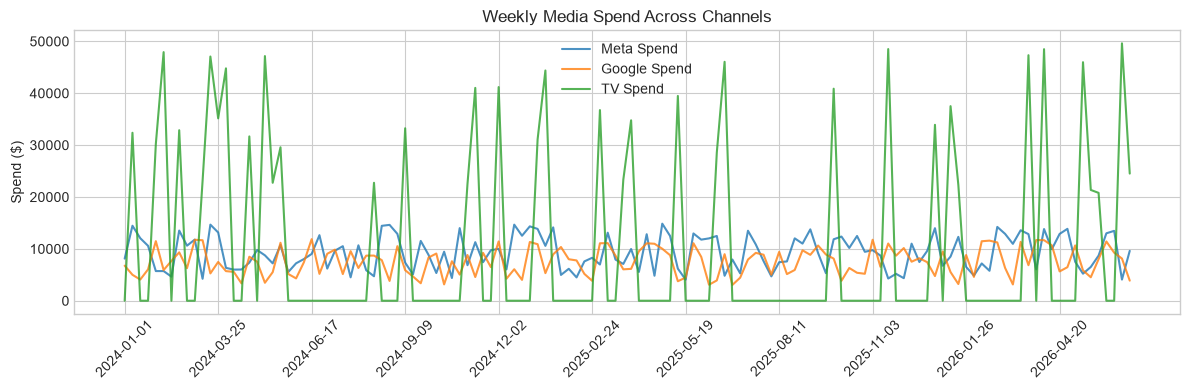

In [5]:
# Load synthetic time-series data
df = pd.read_csv("../data/marketing_data.csv")

# Quick correlation check to spot co-spending patterns
correlations = df[["total_revenue", "meta_spend", "google_spend", "tv_spend"]].corr()
print("Correlation Matrix:")
display(correlations)

# Plot raw media spend over time
plt.figure(figsize=(12, 4))
plt.plot(df['week_start'], df['meta_spend'], label='Meta Spend', alpha=0.8)
plt.plot(df['week_start'], df['google_spend'], label='Google Spend', alpha=0.8)
plt.plot(df['week_start'], df['tv_spend'], label='TV Spend', alpha=0.8)
plt.xticks(df['week_start'][::12], rotation=45)
plt.title("Weekly Media Spend Across Channels")
plt.ylabel("Spend ($)")
plt.legend()
plt.tight_layout()
plt.show()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [baseline_intercept, beta_meta, beta_google, beta_tv, beta_promo, sigma]


/Users/julianlehane/Projects/marketing-analytics-stack/.venv/lib/python3.13/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 2 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


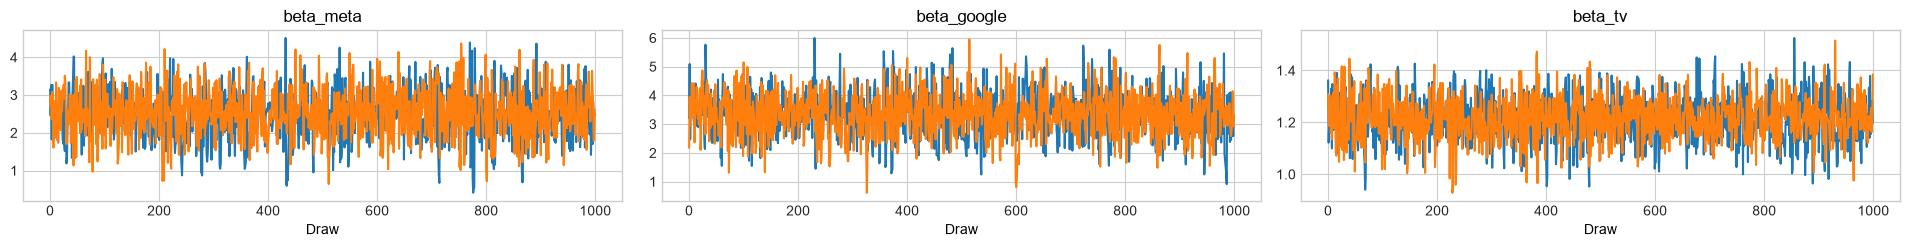

In [6]:
# Load raw features
y = df['total_revenue'].to_numpy(dtype=float) / 10000.0
x_meta = df['meta_spend'].to_numpy(dtype=float) / 10000.0
x_google = df['google_spend'].to_numpy(dtype=float) / 10000.0
x_tv = df['tv_spend'].to_numpy(dtype=float) / 10000.0
x_promo = df['promo_flag'].to_numpy(dtype=float)

# Fit model interactively
with pm.Model() as notebook_model:
    intercept = pm.Normal("baseline_intercept", mu=4.5, sigma=1.0)
    beta_meta = pm.HalfNormal("beta_meta", sigma=2.0)
    beta_google = pm.HalfNormal("beta_google", sigma=2.0)
    beta_tv = pm.Normal("beta_tv", mu=0.91, sigma=0.10) # Calibrated Prior
    beta_promo = pm.Normal("beta_promo", mu=1.5, sigma=0.5)
    sigma = pm.Exponential("sigma", lam=1.0)
    
    mu = intercept + (beta_meta * x_meta) + (beta_google * x_google) + (beta_tv * x_tv) + (beta_promo * x_promo)
    likelihood = pm.Normal("likelihood", mu=mu, sigma=sigma, observed=y)
    
    idata = pm.sample(draws=1000, tune=1000, chains=2, return_inferencedata=True, random_seed=42)

# Plot interactive MCMC Trace (Sampling behavior and convergence)
az.plot_trace(idata, var_names=["beta_meta", "beta_google", "beta_tv"])
plt.tight_layout()
plt.show()